### Imports

In [1]:
!pip install pycountry mlflow -q

In [53]:
from datasets import load_dataset
import plotly.express as px
import pycountry
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import mlflow
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_colwidth', None)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data Loading

In [4]:
ds = load_dataset("papluca/language-identification")
ds

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})

### Data Exploration

In [5]:
train_ds = ds['train'].to_pandas()
valid_ds = ds['validation'].to_pandas()
test_ds = ds['test'].to_pandas()
train_ds


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .
...,...,...
69995,ja,本格的なゲーミングヘッドホンでした。 今まで使ってた1万円するパナソニックのヘッドホンは何だ...
69996,el,"Ναι , ξέρω ένα που είναι ακόμα έτσι , αλλά αυτ..."
69997,ur,اور مجھے اس ملک کے بارے میں معلوم نہیں ہے کہ گ...
69998,es,Se me rompió uno al sacarlo del cargador. Cali...


In [6]:
px.bar(train_ds['labels'].value_counts())

In [7]:
languages = train_ds['labels'].unique()
print(f"There are {len(languages)}")
print(f"Languages: {languages}")

There are 20
Languages: ['pt' 'bg' 'zh' 'th' 'ru' 'pl' 'ur' 'sw' 'tr' 'es' 'ar' 'it' 'hi' 'de'
 'el' 'nl' 'fr' 'vi' 'en' 'ja']


In [8]:
def get_language_name(code):
    try:
        return pycountry.languages.get(alpha_2=code).name
    except AttributeError:
        return "Unknown"

# Map the codes from your dataset
full_names = {code: get_language_name(code) for code in languages}
print(full_names)

{'pt': 'Portuguese', 'bg': 'Bulgarian', 'zh': 'Chinese', 'th': 'Thai', 'ru': 'Russian', 'pl': 'Polish', 'ur': 'Urdu', 'sw': 'Swahili (macrolanguage)', 'tr': 'Turkish', 'es': 'Spanish', 'ar': 'Arabic', 'it': 'Italian', 'hi': 'Hindi', 'de': 'German', 'el': 'Modern Greek (1453-)', 'nl': 'Dutch', 'fr': 'French', 'vi': 'Vietnamese', 'en': 'English', 'ja': 'Japanese'}


### Preprocessing


1. normalize unicode: It makes visually or semantically equivalent characters become consistent internally.

2. lower casing
3. remove extra spaces
4. remove spaces at the begginning and the end of the text

problem solved by normalize unicode:

```python
text1 = "café"
text2 = "café"
text1 == text2

False
```
```python
text1 = unicodedata.normalize("NFKC", text1)
text2 = unicodedata.normalize("NFKC", text2)
text1 == text2

True
```

In [9]:
def preprocess(text):
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [10]:
train_ds['preprocessed_text'] = train_ds['text'].apply(preprocess)
valid_ds['text'] = valid_ds['text'].apply(preprocess)
test_ds['text'] = test_ds['text'].apply(preprocess)
train_ds

,labels,text,preprocessed_text
0,pt,"os chefes de defesa da estónia, letónia, lituâ...","os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,"很好,以前从不去评价,不知道浪费了多少积分,现在知道积分可以换钱,就要好好评价了,后来我就把..."
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,สําหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ขอ...
4,ru,Он увеличил давление .,он увеличил давление .
...,...,...,...
69995,ja,本格的なゲーミングヘッドホンでした。 今まで使ってた1万円するパナソニックのヘッドホンは何だ...,本格的なゲーミングヘッドホンでした。 今まで使ってた1万円するパナソニックのヘッドホンは何だ...
69996,el,"Ναι , ξέρω ένα που είναι ακόμα έτσι , αλλά αυτ...","ναι , ξέρω ένα που είναι ακόμα έτσι , αλλά αυτ..."
69997,ur,اور مجھے اس ملک کے بارے میں معلوم نہیں ہے کہ گ...,اور مجھے اس ملک کے بارے میں معلوم نہیں ہے کہ گ...
69998,es,Se me rompió uno al sacarlo del cargador. Cali...,se me rompió uno al sacarlo del cargador. cali...


In [63]:
# shuffling
train_ds = train_ds.sample(frac=1, random_state=42)

### Embedding & Training

In [29]:
mlflow.set_experiment("language-detection")
import joblib
import os

def train_and_log_tfidf(ngram_range, max_features=30000):
    run_name = f"lr-tfidf-{ngram_range}-feat{max_features}"

    with mlflow.start_run(run_name=run_name) as run:
        # 1. Vectorization
        vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=max_features)
        X_train = vectorizer.fit_transform(train_ds['preprocessed_text'])
        X_valid = vectorizer.transform(valid_ds['text'])

        # 2. Training
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, train_ds['labels'])

        # 3. Evaluation
        preds = model.predict(X_valid)
        acc = accuracy_score(valid_ds['labels'], preds)

        # 4. Logging
        mlflow.sklearn.log_model(model, "model")
        mlflow.log_param("ngram_range", ngram_range)
        mlflow.log_param("max_features", max_features)
        mlflow.log_metric("accuracy", acc)

        # Save and Log Vectorizer
        joblib.dump(vectorizer, "vectorizer.pkl")
        mlflow.log_artifact("vectorizer.pkl")

        # Confusion Matrix
        fig, ax = plt.subplots(figsize=(12, 12))
        ConfusionMatrixDisplay.from_predictions(
            valid_ds['labels'], preds, display_labels=model.classes_,
            ax=ax, cmap='Blues', normalize='true'
        )
        plt.title(f"CM: {run_name}")
        plt.savefig("temp_cm.png")
        mlflow.log_artifact("temp_cm.png")
        plt.show()
        plt.close(fig)

        print(f"Finished {run_name} | Run ID: {run.info.run_id} | Accuracy: {acc:.4f}")
        return model, vectorizer, acc

##### TF-IDF 30k with ngram(1, 2)

2026/05/18 20:38:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 20:38:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


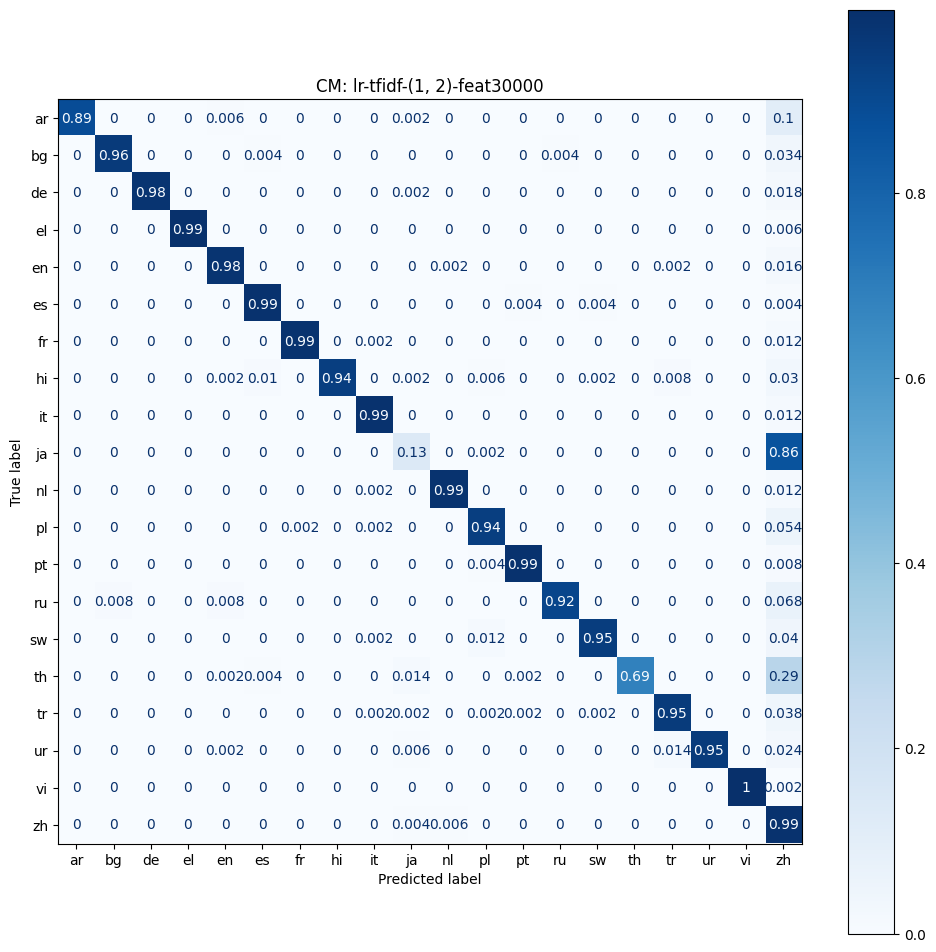

Finished lr-tfidf-(1, 2)-feat30000 | Run ID: 09033d9a994446449ad49e2e05ee2ff2 | Accuracy: 0.9097


In [30]:
model, vectorizer, acc = train_and_log_tfidf(ngram_range=(1, 2), max_features=30000)

##### TF-IDF 30k with ngram(2, 5)

2026/05/18 20:39:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 20:39:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


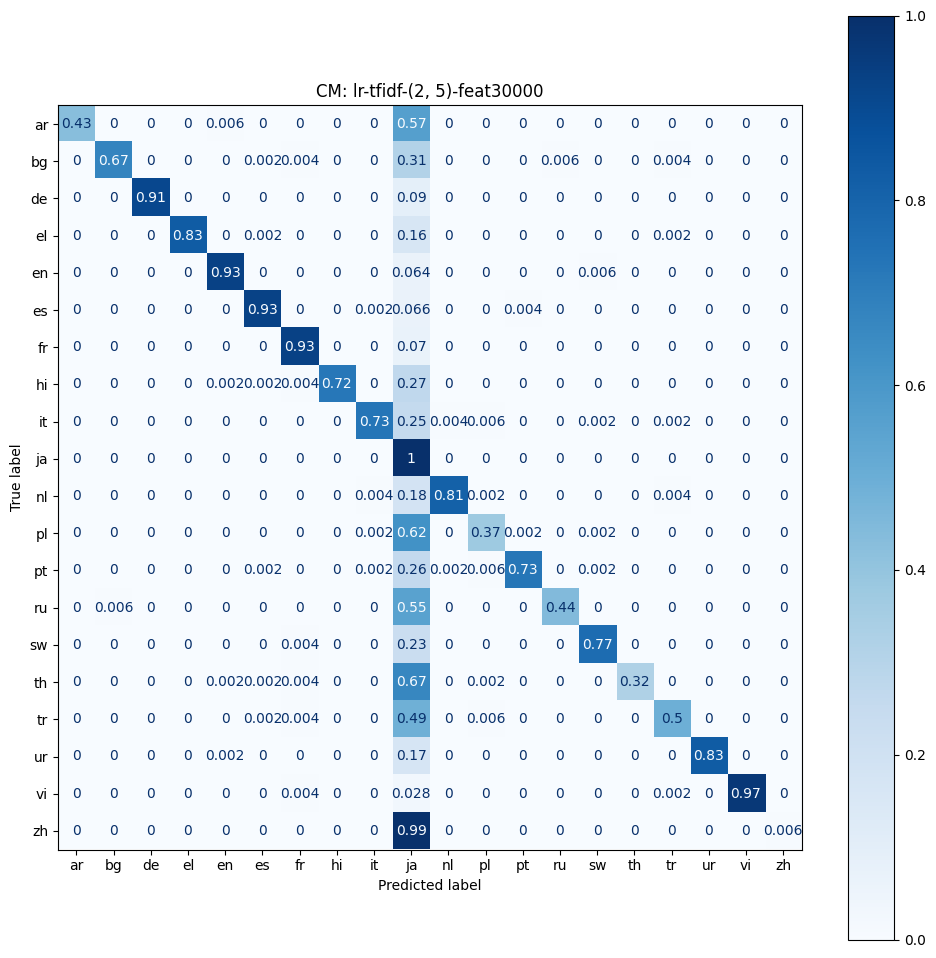

Finished lr-tfidf-(2, 5)-feat30000 | Run ID: c0d0e6c5c4f44797acda5c20daccda9a | Accuracy: 0.6915


In [31]:
model, vectorizer, acc = train_and_log_tfidf(ngram_range=(2, 5), max_features=30000)

##### TF-IDF 30k with ngram(1, 5)

2026/05/18 20:44:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 20:44:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


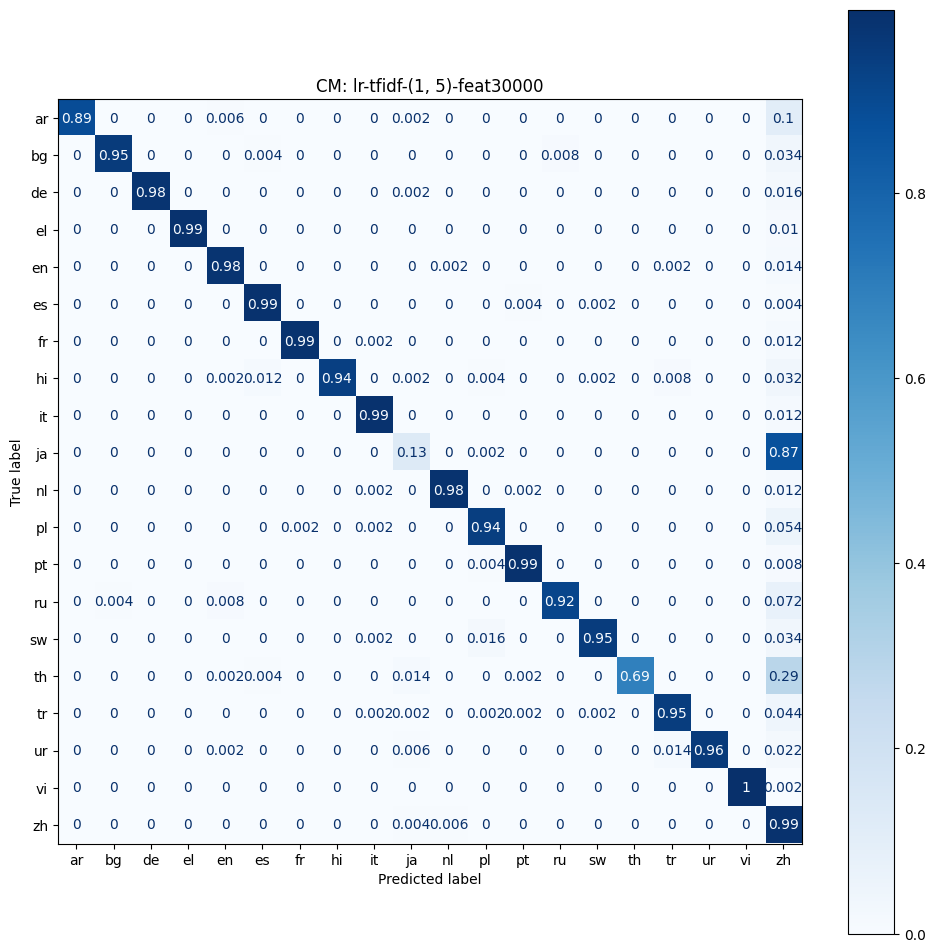

Finished lr-tfidf-(1, 5)-feat30000 | Run ID: 71210afa7bfb4ce4976e4f996241d0a1 | Accuracy: 0.9091


In [32]:
model, vectorizer, acc = train_and_log_tfidf(ngram_range=(1, 5), max_features=30000)

##### TF-IDF 30k with ngram(1, 5)

2026/05/18 20:46:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 20:46:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


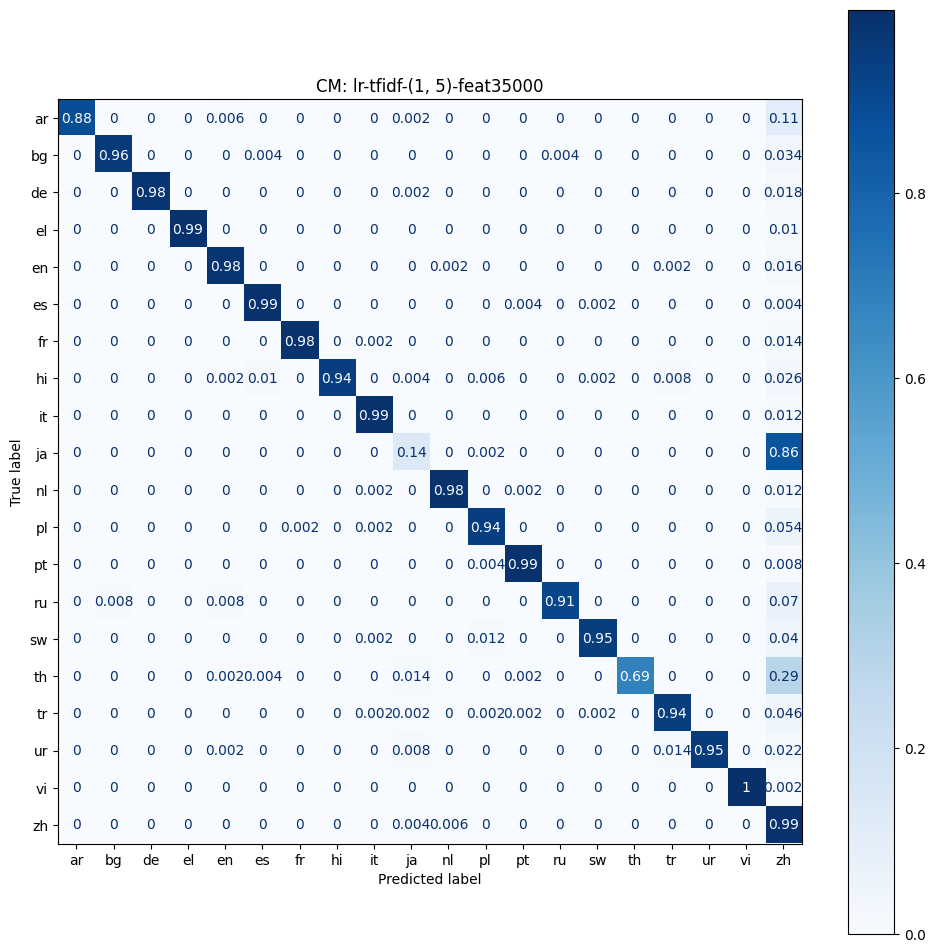

Finished lr-tfidf-(1, 5)-feat35000 | Run ID: 636a38d1f6fa42cd8745564b4ff9bde8 | Accuracy: 0.9091


In [33]:
model, vectorizer, acc = train_and_log_tfidf(ngram_range=(1, 5), max_features=35000)

In [82]:
mlflow.set_experiment("language-detection")
import joblib
import os

def train_and_log_tfidf(ngram_range, analyzer, max_features=30000):
    run_name = f"lr-tfidf-{ngram_range}-feat{max_features}-analyzer-{analyzer}"

    with mlflow.start_run(run_name=run_name) as run:
        # 1. Vectorization
        vectorizer = TfidfVectorizer(
            ngram_range=ngram_range,
            analyzer=analyzer,
            max_features=max_features)
        X_train = vectorizer.fit_transform(train_ds['preprocessed_text'])
        X_valid = vectorizer.transform(valid_ds['text'])

        # 2. Training
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, train_ds['labels'])

        # 3. Evaluation
        preds = model.predict(X_valid)
        acc = accuracy_score(valid_ds['labels'], preds)

        # 4. Logging
        mlflow.sklearn.log_model(model, "model")
        mlflow.log_param("ngram_range", ngram_range)
        mlflow.log_param("max_features", max_features)
        mlflow.log_metric("accuracy", acc)

        # Save and Log Vectorizer
        joblib.dump(vectorizer, "vectorizer.pkl")
        mlflow.log_artifact("vectorizer.pkl")

        # Confusion Matrix
        fig, ax = plt.subplots(figsize=(12, 12))
        ConfusionMatrixDisplay.from_predictions(
            valid_ds['labels'], preds, display_labels=model.classes_,
            ax=ax, cmap='Blues', normalize='true'
        )
        plt.title(f"CM: {run_name}")
        plt.savefig("temp_cm.png")
        mlflow.log_artifact("temp_cm.png")
        plt.show()
        plt.close(fig)

        print(f"Finished {run_name} | Run ID: {run.info.run_id} | Accuracy: {acc:.4f}")
        return model, vectorizer, acc

##### TF-IDF 30k with ngram(1, 2) analyzer='char'

2026/05/18 21:08:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 21:08:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


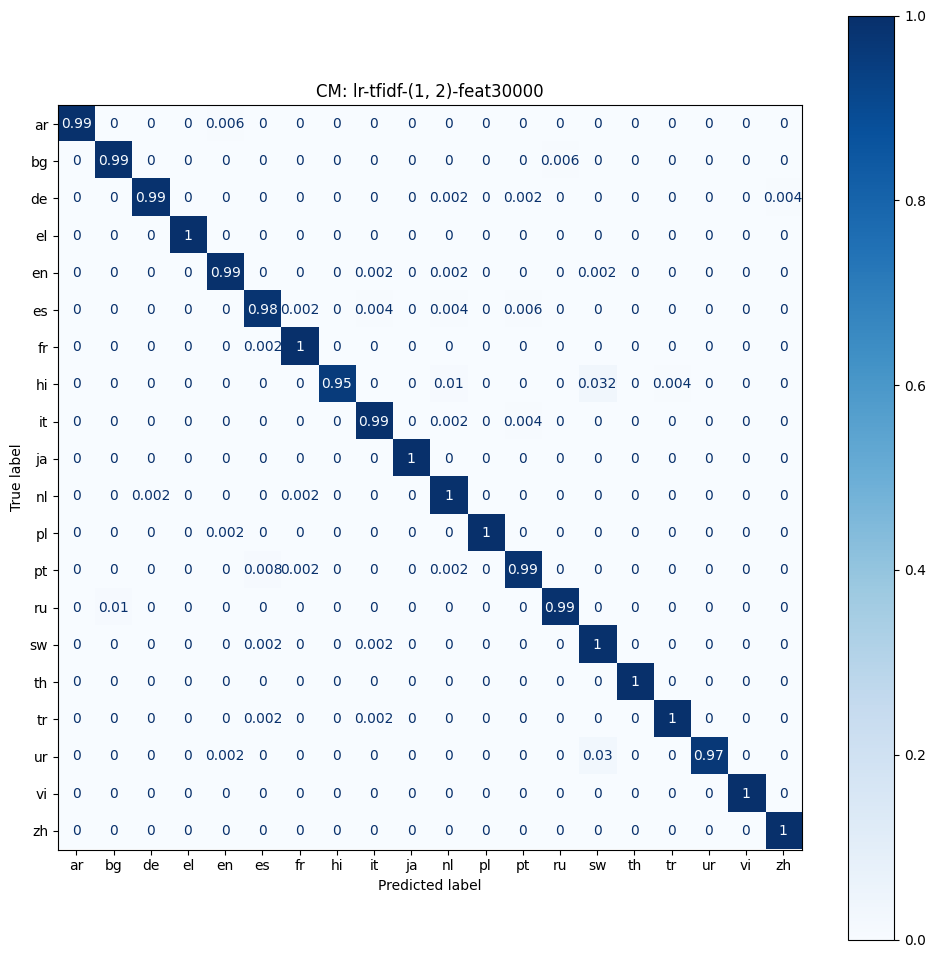

Finished lr-tfidf-(1, 2)-feat30000 | Run ID: 9d97e42b0fb746d082fb77550ff89663 | Accuracy: 0.9918


In [35]:
model, vectorizer, acc = train_and_log_tfidf((1, 2), analyzer='char', max_features=30000)

##### TF-IDF 30k with ngram(1, 3) analyzer='char'

2026/05/18 21:34:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 21:34:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


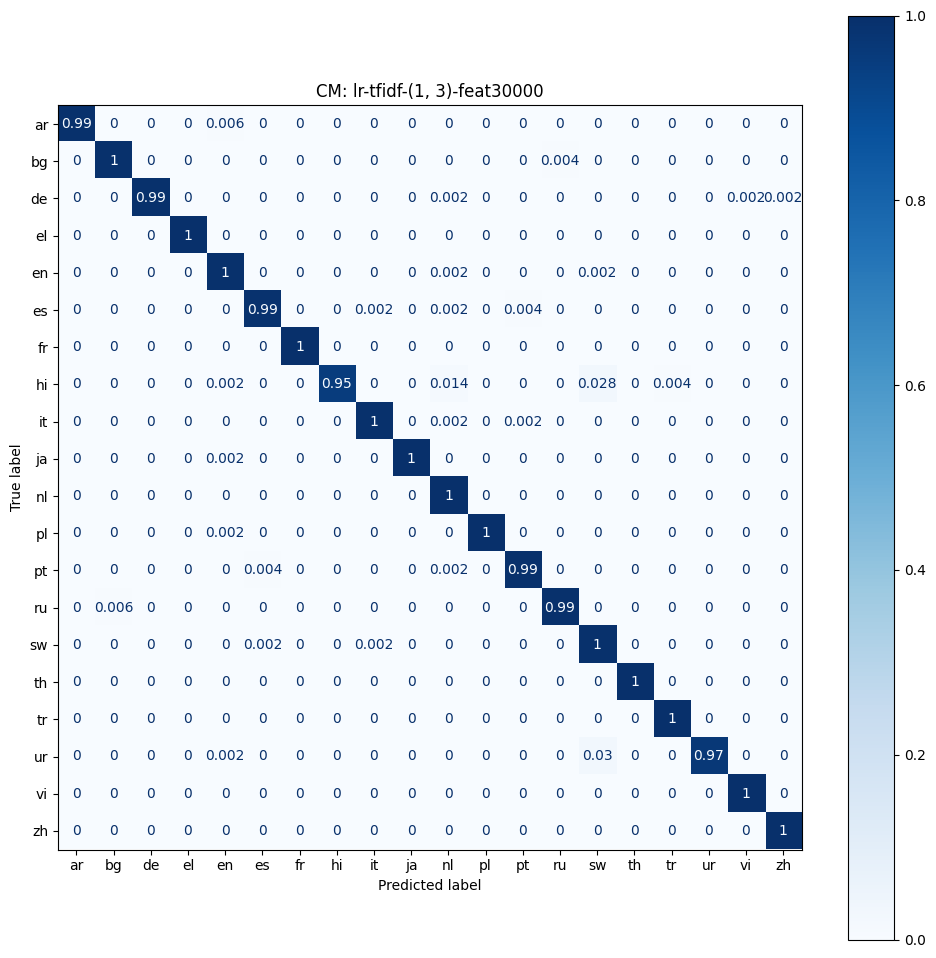

Finished lr-tfidf-(1, 3)-feat30000 | Run ID: 1649d8739ed44186b6f11ec1f0852ddc | Accuracy: 0.9934


In [64]:
model, vectorizer, acc = train_and_log_tfidf((1, 3), analyzer='char', max_features=30000)

##### TF-IDF 30k with ngram(1, 2) analyzer='char_wb'

2026/05/18 21:53:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 21:53:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


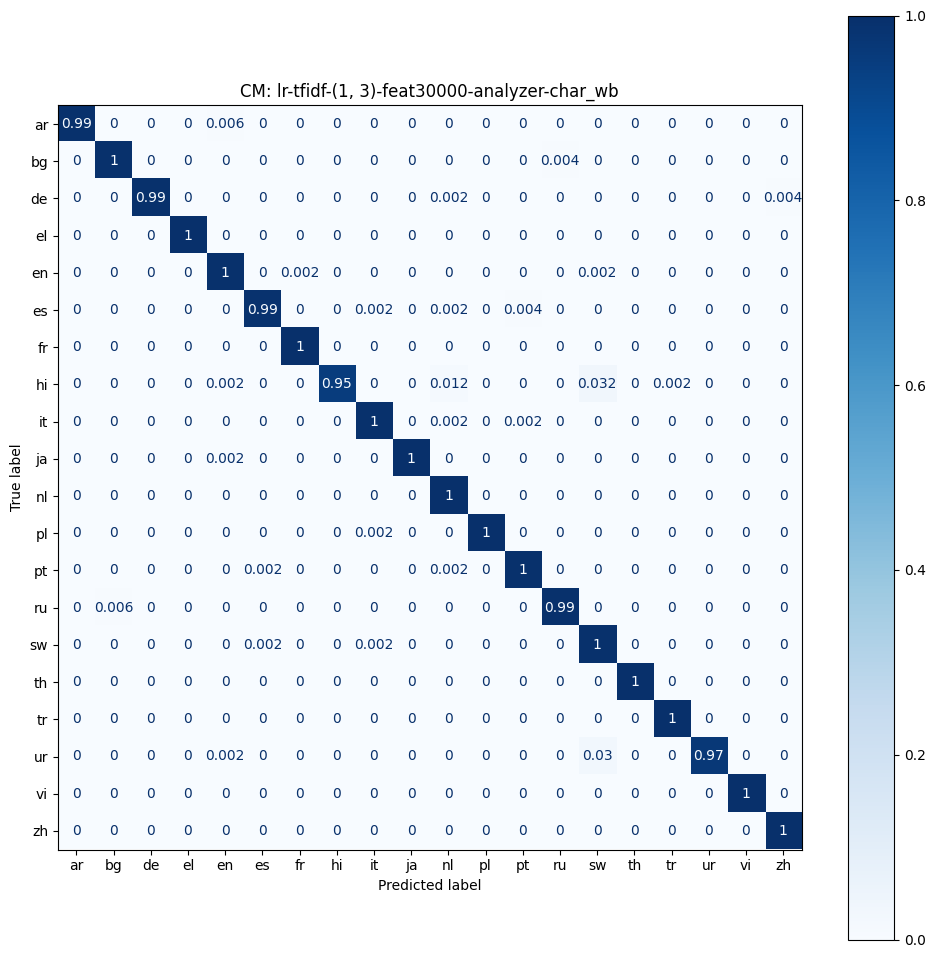

Finished lr-tfidf-(1, 3)-feat30000-analyzer-char_wb | Run ID: eee2b92cd34f4576a0d24a7623cb4fe9 | Accuracy: 0.9935


In [83]:
model, vectorizer, acc = train_and_log_tfidf((1, 3), analyzer='char_wb', max_features=30000)

2026/05/18 21:56:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 21:56:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


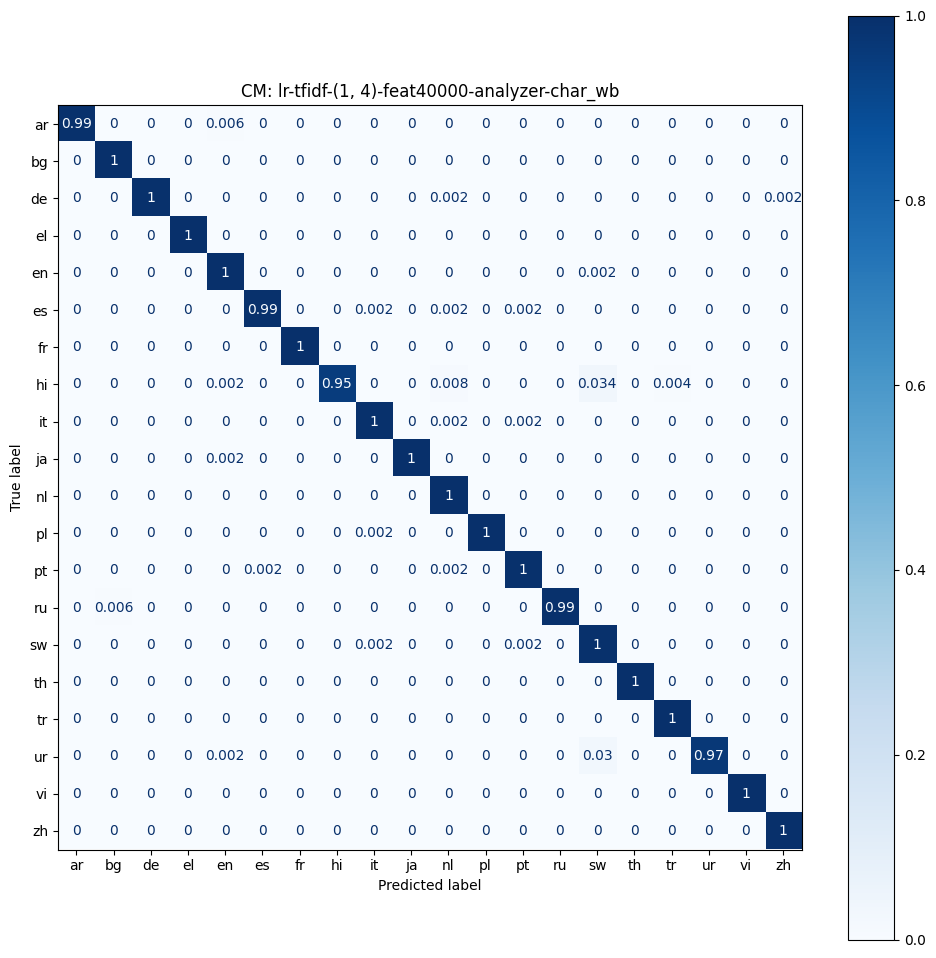

Finished lr-tfidf-(1, 4)-feat40000-analyzer-char_wb | Run ID: a6d8597a22fa4bab936d004945da1dbf | Accuracy: 0.9940


In [87]:
model, vectorizer, acc = train_and_log_tfidf((1, 4), analyzer='char_wb', max_features=40000)

2026/05/18 22:10:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 22:10:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


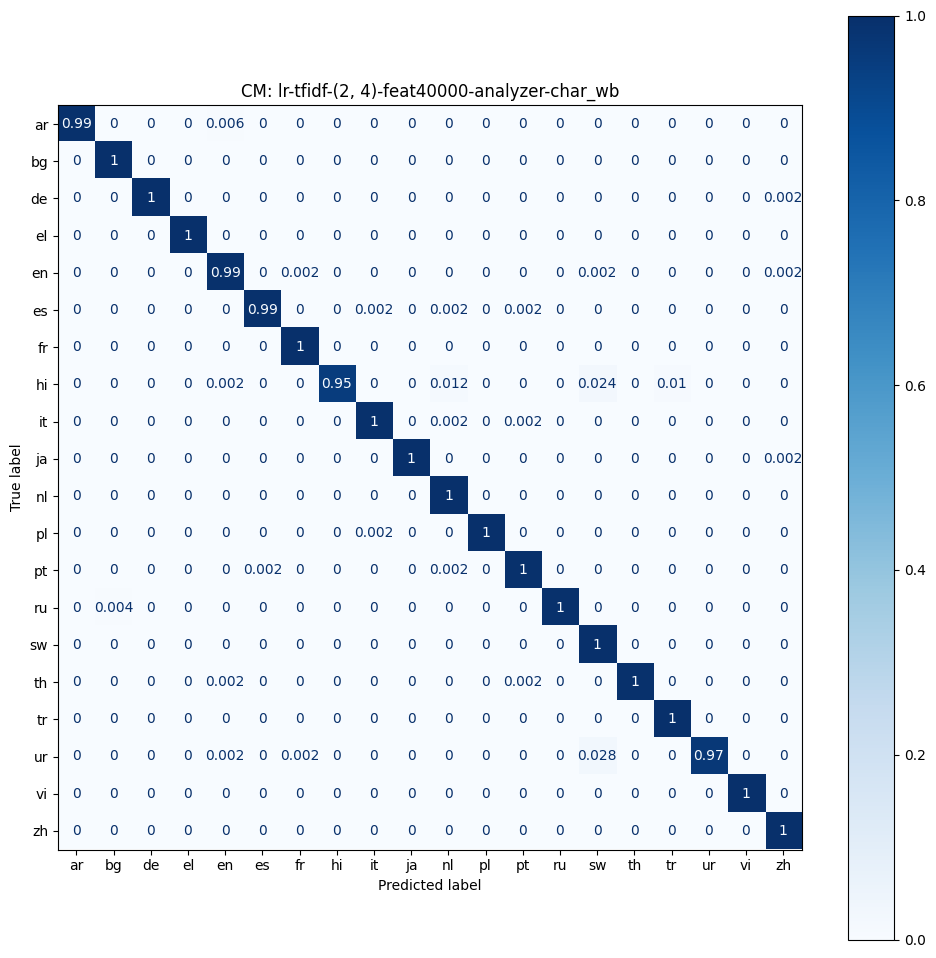

Finished lr-tfidf-(2, 4)-feat40000-analyzer-char_wb | Run ID: c2bc6437ad0f4d97bfb0c40ed7ccd3c3 | Accuracy: 0.9940


In [111]:
model, vectorizer, acc = train_and_log_tfidf((2, 4), analyzer='char_wb', max_features=40000)


#### Test Examples

In [112]:
text = "انا اسمي بيتر"
model.predict(vectorizer.transform([text]))

array(['ar'], dtype=object)

In [123]:
text = "hi my name is peter"
prec_text = preprocess(text)
model.predict(vectorizer.transform([prec_text]))

array(['sw'], dtype=object)

In [94]:
text = "je suis malade"
prec_text = preprocess(text)
model.predict(vectorizer.transform([prec_text]))

array(['fr'], dtype=object)

In [95]:
text = "ภาษาไทย"
prec_text = preprocess(text)
model.predict(vectorizer.transform([prec_text]))

array(['th'], dtype=object)

In [96]:
text = "こんにちは"
prec_text = preprocess(text)
model.predict(vectorizer.transform([prec_text]))

array(['ja'], dtype=object)

In [48]:
model.classes_

array(['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl',
       'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh'], dtype=object)

In [59]:
txt_containing_hi = train_ds[train_ds['preprocessed_text'].str.contains('hi ')]
txt_containing_hi

,labels,text,preprocessed_text
7,sw,"Zabuni ya ushindani pia imekuwa rahisi kwa sifa ya kurudi kwenye mapendekezo yake ya grant , na dudovitz hivi karibuni ilikuwa kulea kwa ajili ya kuendeleza nyenzo za matangazo ya slick na kushiriki fedha kwa mipango nyingine ya mapendeleo ya umma kwa juhudi za shirikishi za afya , utetezi wa sera , homelessness , nyumbani msaada wa vurugu , msaada wa kibinafsi na maendeleo ya teknolojia .","zabuni ya ushindani pia imekuwa rahisi kwa sifa ya kurudi kwenye mapendekezo yake ya grant , na dudovitz hivi karibuni ilikuwa kulea kwa ajili ya kuendeleza nyenzo za matangazo ya slick na kushiriki fedha kwa mipango nyingine ya mapendeleo ya umma kwa juhudi za shirikishi za afya , utetezi wa sera , homelessness , nyumbani msaada wa vurugu , msaada wa kibinafsi na maendeleo ya teknolojia ."
67,vi,"Sau một thời kỳ từ chối , các monaster y đã được giải tán ngay cả trước khi cuộc cách mạng .","sau một thời kỳ từ chối , các monaster y đã được giải tán ngay cả trước khi cuộc cách mạng ."
93,bg,"важен град в роман гале , който заменя лион като столица към края на империята , арл се гордее с много добре запазен amphi ? театър ( arynes ) , места над 20,000 в дните на гладиаторите .","важен град в роман гале , който заменя лион като столица към края на империята , арл се гордее с много добре запазен amphi ? театър ( arynes ) , места над 20,000 в дните на гладиаторите ."
282,it,Gli attacchi aerei israeliani uccidono 16 persone a Gaza,gli attacchi aerei israeliani uccidono 16 persone a gaza
360,sw,"Mara kwa mara , mmoja anatamani kuwa foster wange kutoka kwa meza yake ya maelezo na uchunguzi wa eneo kubwa la fasihi .","mara kwa mara , mmoja anatamani kuwa foster wange kutoka kwa meza yake ya maelezo na uchunguzi wa eneo kubwa la fasihi ."
...,...,...,...
69839,vi,Ở Góc Đông Bắc là một hầm mộ nơi mà một bộ nhớ tạm của kho báu đã được đào tạo trong khi khai quật .,ở góc đông bắc là một hầm mộ nơi mà một bộ nhớ tạm của kho báu đã được đào tạo trong khi khai quật .
69842,vi,"Dữ liệu đáng tin cậy khi họ là ( 1 ) hoàn thành ( họ chứa tất cả các yếu tố dữ liệu và hồ sơ cần thiết cho tương tác ) 2 và ( 2 ) chính xác ( họ phản ánh dữ liệu được nhập vào nguồn hoặc , nếu có , trong các tài liệu nguồn ) -Không .","dữ liệu đáng tin cậy khi họ là ( 1 ) hoàn thành ( họ chứa tất cả các yếu tố dữ liệu và hồ sơ cần thiết cho tương tác ) 2 và ( 2 ) chính xác ( họ phản ánh dữ liệu được nhập vào nguồn hoặc , nếu có , trong các tài liệu nguồn ) -không ."
69873,vi,"Trong tương phản , các nhà sản xuất động vật nonruminant có thể tăng lên đến 162 triệu đô-la trong chi phí thấp hơn .","trong tương phản , các nhà sản xuất động vật nonruminant có thể tăng lên đến 162 triệu đô-la trong chi phí thấp hơn ."
69917,vi,Ở mức chi phí của lớp trung học .,ở mức chi phí của lớp trung học .


In [60]:
px.bar(txt_containing_hi['labels'].value_counts())

In [70]:
feature_names = vectorizer.get_feature_names_out()
class_index = list(model.classes_).index('en')
top_features = sorted(zip(model.coef_[class_index], feature_names), reverse=True)[:20]
print(top_features)

[(np.float64(4.126230628877779), 't'), (np.float64(3.850145555809574), 'th'), (np.float64(3.6034793459818797), 'd '), (np.float64(3.1787456705163737), 't '), (np.float64(2.9175198436643917), 'y '), (np.float64(2.586895865846428), 'ed'), (np.float64(2.558467623820674), 'ea'), (np.float64(2.5181041889043914), 'the'), (np.float64(2.481933813208926), ' w'), (np.float64(2.432695168988345), ' i'), (np.float64(2.383782745201534), ' th'), (np.float64(2.3518578679538913), ' a'), (np.float64(2.350128618433071), 'ed '), (np.float64(2.30091822364872), ' it'), (np.float64(2.272934058727109), 'y'), (np.float64(2.1890539445029353), 'f'), (np.float64(2.187480810992795), 'o'), (np.float64(2.1588903956036796), '. '), (np.float64(2.099180087669432), 'it'), (np.float64(1.952967812230724), 'not')]


In [75]:
model.coef_.shape

(20, 30000)

In [77]:
len(model.intercept_)

20

#### Test Data

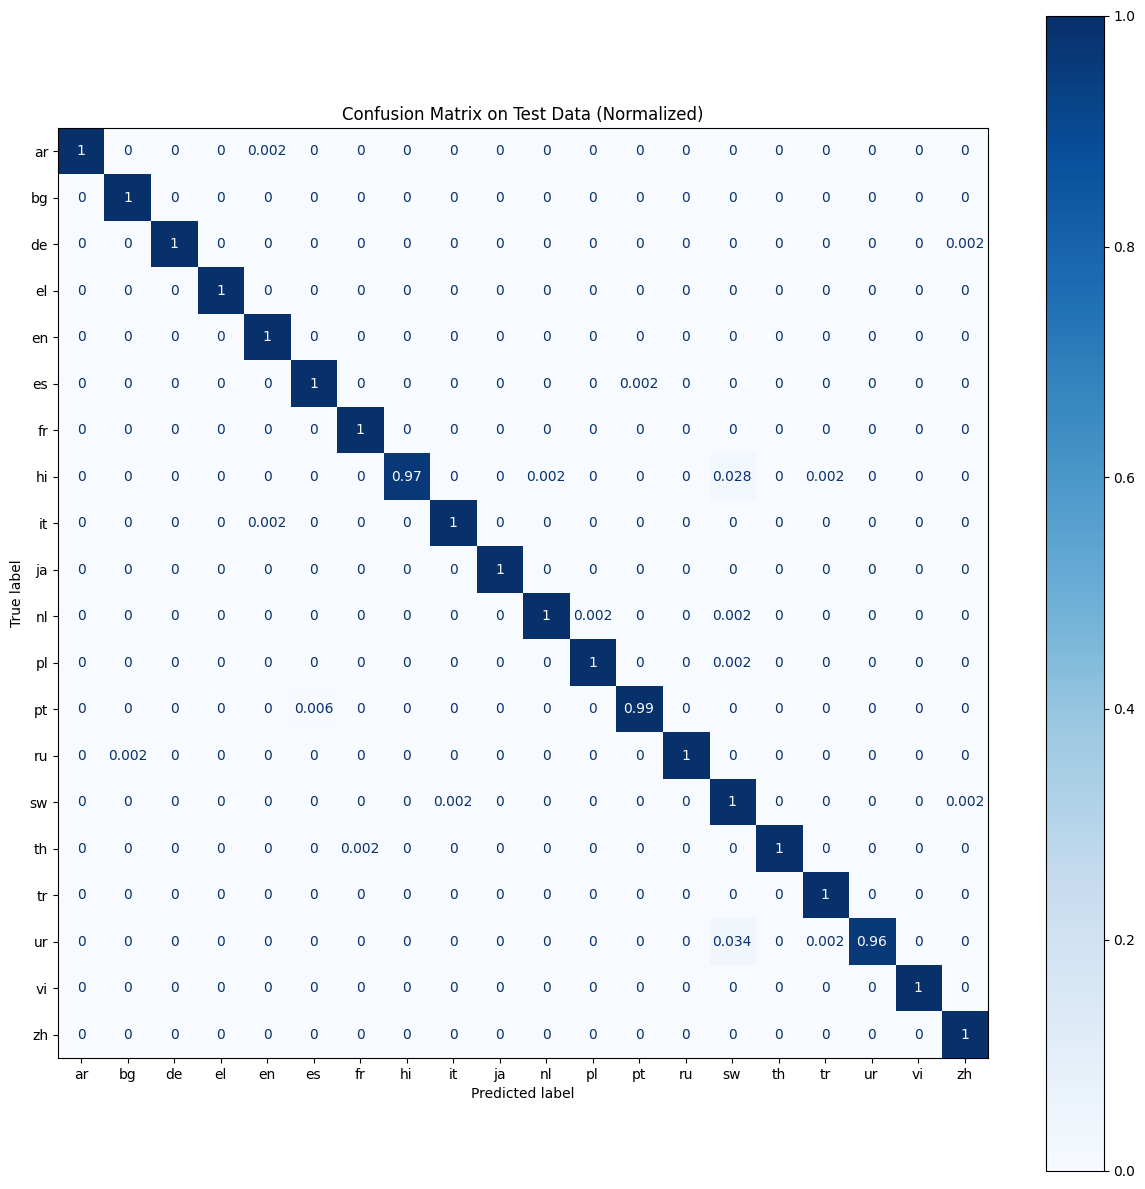

Test Accuracy: 0.9952


In [124]:
# 1. Transform test data and predict
X_test = vectorizer.transform(test_ds['text'])
y_test_pred = model.predict(X_test)

# 2. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(15, 15))
ConfusionMatrixDisplay.from_predictions(
    test_ds['labels'],
    y_test_pred,
    display_labels=model.classes_,
    ax=ax,
    cmap='Blues',
    normalize='true'
)
plt.title("Confusion Matrix on Test Data (Normalized)")
plt.show()

# 3. Print final accuracy
test_acc = accuracy_score(test_ds['labels'], y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")